In [1]:
from google.colab import files
uploaded = files.upload()

Saving openai_10_fake_posts_judge_dataset.json to openai_10_fake_posts_judge_dataset.json


In [2]:
!pip install openai python-dotenv

In [4]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get('OPENAI_API_KEY')
)

In [5]:
import json
import pandas as pd

with open("openai_10_fake_posts_judge_dataset.json", "r") as f:
    posts = json.load(f)

posts_df = pd.DataFrame(posts)
posts_df.head()

,post_id,title,subreddit,score,num_comments,combined_text,topic,expected_sentiment
0,P001,OpenAI pricing feels too expensive for students,OpenAI,842,236,ChatGPT Plus and API pricing are becoming too ...,pricing,negative
1,P002,The new OpenAI model is powerful but confusing,ChatGPT,615,154,The latest OpenAI model gives much better answ...,product release,mixed
2,P003,OpenAI should be more transparent about model ...,technology,521,198,Users are frustrated when ChatGPT behavior cha...,transparency,negative
3,P004,ChatGPT helped me finish a coding project faster,learnprogramming,1104,287,"I used ChatGPT to debug Python errors, explain...",productivity,positive
4,P005,OpenAI outage during work hours was frustrating,OpenAI,734,312,ChatGPT went down while many people were using...,reliability,negative


In [6]:
def dedicated_judge(post, judge_type):

    questions = {
        "crisis_alert": "Is the severity level justified?",
        "executive_summary": "Is the insight accurate and coherent?",
        "recommendations": "Is the advice sound and actionable?"
    }

    prompt = f"""
You are an LLM judge.

Post title:
{post['title']}

Post text:
{post['combined_text']}

cRI

Expected sentiment:
{post['expected_sentiment']}

Judge type:
{judge_type}

Judge question:
{questions[judge_type]}

Score from 0 to 10.

Return JSON only:
{{
  "post_id": "{post['post_id']}",
  "judge_type": "{judge_type}",
  "score": 0,
  "context": "short explanation",
  "feedback_loop": "what should be revised"
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )

    return json.loads(response.choices[0].message.content)

In [7]:
judge_results = []

for post in posts:
    for judge_type in ["crisis_alert", "executive_summary", "recommendations"]:
        result = dedicated_judge(post, judge_type)
        judge_results.append(result)

judge_df = pd.DataFrame(judge_results)
judge_df.head(10)

,post_id,judge_type,score,context,feedback_loop
0,P001,crisis_alert,5,The post expresses concern over pricing that m...,Consider providing more specific examples or d...
1,P001,executive_summary,7,The insight accurately conveys concerns about ...,Consider providing specific examples or compar...
2,P001,recommendations,3,The post raises valid concerns about pricing f...,"To improve, the post could include specific re..."
3,P002,crisis_alert,5,The post highlights the confusion surrounding ...,Consider providing specific examples of the co...
4,P002,executive_summary,7,The insight accurately reflects the strengths ...,Clarify the specific areas of confusion in the...
5,P002,recommendations,5,The post highlights both the strengths and wea...,"To improve, the author should include concrete..."
6,P003,crisis_alert,4,The frustration expressed by users indicates a...,Consider providing specific examples of user f...
7,P003,executive_summary,8,The insight accurately highlights user frustra...,"To improve, consider providing specific exampl..."
8,P003,recommendations,7,The advice is sound as transparency can enhanc...,"To improve, the author could provide specific ..."
9,P004,crisis_alert,0,"The sentiment of the post is positive, and the...",No revision needed; the post is positive and r...


In [8]:
judge_df.groupby("judge_type")["score"].mean()

,score
judge_type,
crisis_alert,4.2
executive_summary,7.8
recommendations,6.1


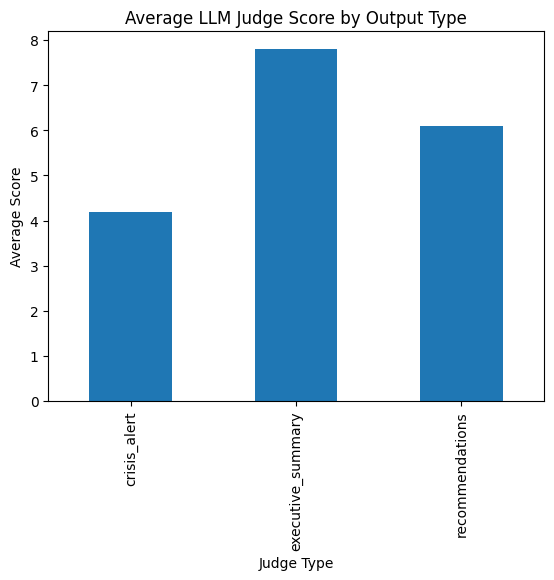

In [9]:
import matplotlib.pyplot as plt

judge_df.groupby("judge_type")["score"].mean().plot(kind="bar")

plt.title("Average LLM Judge Score by Output Type")
plt.ylabel("Average Score")
plt.xlabel("Judge Type")
plt.show()